In [37]:
from langchain.chat_models import init_chat_model
import os
import json

In [38]:
# import getpass
from pathlib import Path

def load_env_file(path: str = ".env") -> bool:
    env_path = Path(path)
    if not env_path.exists():
        return False

    for raw_line in env_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        if key and key not in os.environ:
            os.environ[key] = value

    return True

env_loaded = load_env_file()
print(f".env loaded: {env_loaded}")

LANGSMITH_TRACING = os.getenv("LANGSMITH_TRACING", "false").lower() == "true"
LANGSMITH_API_KEY = os.getenv("LANGSMITH_API_KEY", None)

OLLAMA_MODEL = os.getenv("OLLAMA_MODEL", "kimi-k2:1t-cloud")
OLLAMA_API_KEY = os.getenv("OLLAMA_API_KEY", "ollama")
OLLAMA_MODEL_URL = os.getenv("OLLAMA_MODEL_URL", "http://localhost:11434")

print(f"LANGSMITH_TRACING: {LANGSMITH_TRACING}")
print(f"LANGSMITH_API_KEY: {LANGSMITH_API_KEY or 'not set'}")
print(f"OLLAMA_MODEL: {OLLAMA_MODEL}")
print(f"OLLAMA_API_KEY: {OLLAMA_API_KEY or 'not set'}")
print(f"OLLAMA_MODEL_URL: {OLLAMA_MODEL_URL}")

args = {
  "model": OLLAMA_MODEL,
  "model_provider": "openai",
  "api_key": OLLAMA_API_KEY,
  "base_url": f"{OLLAMA_MODEL_URL}/v1",
}

model = init_chat_model(
  args["model"],
  model_provider=args["model_provider"],
  api_key=args["api_key"],
  base_url=args["base_url"],
)

print(json.dumps(args, indent=2))

.env loaded: True
LANGSMITH_TRACING: True
LANGSMITH_API_KEY: [REDACTED]
OLLAMA_MODEL: kimi-k2:1t-cloud
OLLAMA_API_KEY: ollama
OLLAMA_MODEL_URL: http://localhost:11434
{
  "model": "kimi-k2:1t-cloud",
  "model_provider": "openai",
  "api_key": "ollama",
  "base_url": "http://localhost:11434/v1"
}


In [39]:
from langchain.agents import AgentState
from typing_extensions import NotRequired
from typing import Literal

WorkflowStep = Literal["receptionist", "sports_data_collector", "content_editor", "betting_editor"]
RequestType = Literal["games", "expert_picks", "both"]

class SupportState(AgentState):
    """State for sports games and betting picks workflow."""
    current_step: NotRequired[WorkflowStep]
    request_type: NotRequired[RequestType]
    picks_status: NotRequired[Literal["UPCOMING", "PAST"]]
    league: NotRequired[str]
    start_date: NotRequired[str]
    end_date: NotRequired[str]
    games: NotRequired[list[dict]]
    expert_picks: NotRequired[list[dict]]
    expert_picks_total: NotRequired[int]

In [41]:
from langchain.tools import tool, ToolRuntime
from langchain.messages import ToolMessage
from langgraph.types import Command
import json
import requests

EXPERT_PICKS_QUERY = """query SLUI_ExpertPicks($first: Int = 10, $after: String, $sortBy: [ExpertPickSortByInput!], $filter: ExpertPickFilterInput) {
  expertPicks(first: $first, after: $after, sortBy: $sortBy, filter: $filter) {
    totalCount
    pageInfo {
      startCursor
      endCursor
      hasNextPage
    }
    edges {
      cursor
      node {
        id
        isFeatured
        locked
        createdAt
        resultStatus
        unit
        writeup
        sportsbookName
        game {
            id
            homeTeam {
                id
                abbrev
                nickname
                mediumName
            }
            awayTeam {
                id
                abbrev
                nickname
                mediumName
            }
        }
        expert {
            id
            firstName
            lastName
        }
      }
    }
  }
}
"""

@tool
def request_expert_picks(
    status: Literal["UPCOMING", "PAST"],
    league: str,
    runtime: ToolRuntime[SupportState] = None,
) -> Command:
    """Request expert picks for a given sports league. The league parameter can be 'NFL', 'NBA', 'MLB'."""
    url = "https://helios.cbssports.com/"
    headers = {
        "accept": "*/*",
        "accept-language": "en-US,en;q=0.9,fr;q=0.8,es;q=0.7,zh-CN;q=0.6,zh;q=0.5,pt;q=0.4,de;q=0.3,la;q=0.2",
        "cache-control": "no-cache",
        "content-type": "application/json",
        "helios-client-name": "sportsline-web",
        "origin": "https://www.sportsline.com",
        "pid": "L:1:wNjylykbeW%252BQ7HXfD0npOcRWsoZTVKd9G9Ivc3FOgpukRr0i4BBoWiN8DdgiuIbo:1",
        "pragma": "no-cache",
        "priority": "u=1, i",
        "referer": "https://www.sportsline.com/",
        "sec-ch-ua": '"Not:A-Brand";v="99", "Google Chrome";v="145", "Chromium";v="145"',
        "sec-ch-ua-mobile": "?0",
        "sec-ch-ua-platform": '"macOS"',
        "sec-fetch-dest": "empty",
        "sec-fetch-mode": "cors",
        "sec-fetch-site": "cross-site",
        "user-agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/145.0.0.0 Safari/537.36",
    }
    payload = {
        "operationName": "SLUI_ExpertPicks",
        "variables": {
            "sortBy": [
                {"order": "DESC", "field": "FEATURED"},
                {"order": "DESC", "field": "CREATED"},
            ],
            "filter": {"state": status, "leagues": [league]},
        },
        "query": EXPERT_PICKS_QUERY,
    }

    try:
        response = requests.post(url, headers=headers, json=payload, timeout=15)
        response.raise_for_status()
        data = response.json()
        edges = (
            data.get("data", {})
            .get("expertPicks", {})
            .get("edges", [])
        )

        league_upper = (league or "").upper()
        status_upper = (status or "UPCOMING").upper()

        picks = []
        for edge in edges:
            node = edge.get("node", {})
            expert = node.get("expert", {})
            first_name = expert.get("firstName", "").strip()
            last_name = expert.get("lastName", "").strip()
            full_name = f"{first_name} {last_name}".strip() or "n/a"

            picks.append(
                {
                    "expert_name": full_name,
                    "away_team": node.get("game", {}).get("awayTeam", {}).get("mediumName", "n/a"),
                    "home_team": node.get("game", {}).get("homeTeam", {}).get("mediumName", "n/a"),
                    "writeup": node.get("writeup", "n/a"),
                    "unit": node.get("unit", None),
                    "sportsbook": node.get("sportsbookName", "n/a"),
                    "result_status": node.get("resultStatus", "n/a"),
                    "created_at": node.get("createdAt", "n/a"),
                }
            )

        result = {
            "league": league_upper,
            "status": status_upper,
            "total_picks": data.get("data", {}).get("expertPicks", {}).get("totalCount", 0),
            "returned_edges": len(picks),
            "picks": picks,
        }

        tool_message = ToolMessage(
            content=json.dumps(result, indent=2),
            tool_call_id=runtime.tool_call_id if runtime else "",
        )

        return Command(
            update={
                "league": league_upper,
                "picks_status": status_upper,
                "expert_picks_total": result["total_picks"],
                "expert_picks": picks,
                "messages": [tool_message],
            }
        )
    except requests.HTTPError:
        status_code = response.status_code if "response" in locals() else "unknown"
        error_text = response.text[:2000] if "response" in locals() else "no response body"
        tool_message = ToolMessage(
            content=f"HTTP {status_code}: {error_text}",
            tool_call_id=runtime.tool_call_id if runtime else "",
        )
        return Command(update={"messages": [tool_message]})
    except requests.RequestException as e:
        tool_message = ToolMessage(
            content=f"Error fetching expert picks for {league}: {e}",
            tool_call_id=runtime.tool_call_id if runtime else "",
        )
        return Command(update={"messages": [tool_message]})

# request_expert_picks.invoke({"status": "UPCOMING", "league": "NBA"})

In [42]:
# primpy url
PRIMPY_TOKEN = os.getenv("PRIMPY_TOKEN", "")
PRIMPY_URL = "https://api.cbssports.com/primpy/sportsline"

from datetime import date, timedelta
import calendar
import re

def _month_bounds(year: int, month: int) -> tuple[date, date]:
    last_day = calendar.monthrange(year, month)[1]
    return date(year, month, 1), date(year, month, last_day)

def _week_bounds(anchor: date, offset_weeks: int = 0) -> tuple[date, date]:
    # Weeks are Monday-Sunday.
    start = anchor - timedelta(days=anchor.weekday()) + timedelta(weeks=offset_weeks)
    end = start + timedelta(days=6)
    return start, end

def _resolve_single_range(text: str, today: date) -> tuple[date, date, str]:
    t = (text or "").strip().lower()

    if not t or t in {"today", "for today"}:
        return today, today, "today"
    if t in {"tomorrow", "for tomorrow"}:
        d = today + timedelta(days=1)
        return d, d, "tomorrow"
    if t in {"yesterday"}:
        d = today - timedelta(days=1)
        return d, d, "yesterday"

    if "this week" in t or "current week" in t:
        s, e = _week_bounds(today, 0)
        return s, e, "this_week"
    if "next week" in t or "upcoming week" in t:
        s, e = _week_bounds(today, 1)
        return s, e, "next_week"
    if "last week" in t or "past week" in t or "previous week" in t:
        s, e = _week_bounds(today, -1)
        return s, e, "past_week"

    if "this month" in t or "current month" in t:
        s, e = _month_bounds(today.year, today.month)
        return s, e, "this_month"
    if "next month" in t or "upcoming month" in t:
        if today.month == 12:
            y, m = today.year + 1, 1
        else:
            y, m = today.year, today.month + 1
        s, e = _month_bounds(y, m)
        return s, e, "next_month"
    if "last month" in t or "past month" in t or "previous month" in t:
        if today.month == 1:
            y, m = today.year - 1, 12
        else:
            y, m = today.year, today.month - 1
        s, e = _month_bounds(y, m)
        return s, e, "past_month"

    if "next couple of days" in t or "next few days" in t:
        return today, today + timedelta(days=2), "next_2_days"

    next_days_match = re.search(r"\bnext\s+(\d+)\s+days?\b", t)
    if next_days_match:
        days = max(1, min(60, int(next_days_match.group(1))))
        return today, today + timedelta(days=days), f"next_{days}_days"

    past_days_match = re.search(r"\b(?:past|last|previous)\s+(\d+)\s+days?\b", t)
    if past_days_match:
        days = max(1, min(60, int(past_days_match.group(1))))
        return today - timedelta(days=days), today, f"past_{days}_days"

    # Fallback for unspecified natural language; keep safe default.
    return today, today + timedelta(days=2), "fallback_next_2_days"

@tool
def resolve_game_date_range(date_text: str) -> str:
    """Resolve natural-language game date text to start/end dates in YYYYMMDD.

    Examples handled:
    - "today", "tomorrow", "yesterday"
    - "this week", "next week", "past week"
    - "this month", "next month", "past month"
    - "from today until next week"
    - "next couple of days" / "next 2 days" / "past 7 days"
    """
    text = (date_text or "").strip()
    normalized = text.lower()
    today = date.today()

    # Range phrases: "from A until B", "between A and B".
    range_match = re.search(
        r"\bfrom\s+(.+?)\s+(?:to|until|through|thru)\s+(.+)\b|\bbetween\s+(.+?)\s+and\s+(.+)\b",
        normalized,
    )

    if range_match:
        left = (range_match.group(1) or range_match.group(3) or "").strip()
        right = (range_match.group(2) or range_match.group(4) or "").strip()
        s1, e1, i1 = _resolve_single_range(left, today)
        s2, e2, i2 = _resolve_single_range(right, today)
        start = min(s1, s2)
        end = max(e1, e2)
        interpreted = f"range:{i1}_to_{i2}"
    else:
        start, end, interpreted = _resolve_single_range(normalized, today)

    result = {
        "input": date_text,
        "start_date": start.strftime("%Y%m%d"),
        "end_date": end.strftime("%Y%m%d"),
        "today": today.strftime("%Y%m%d"),
        "interpreted_as": interpreted,
        "note": "Use start_date/end_date with capture_user_request for games flow.",
    }
    return json.dumps(result, indent=2)

@tool
def capture_user_request(
    request_type: Literal["games", "expert_picks", "both"],
    league: str = "",
    start_date: str = "",
    end_date: str = "",
    picks_status: Literal["UPCOMING", "PAST"] = "UPCOMING",
    runtime: ToolRuntime[SupportState] = None,
) -> Command:
    """Capture user intent and route to games, expert picks, or a combined flow.

    - request_type='games' requires start_date and end_date in YYYYMMDD format.
    - request_type='expert_picks' routes to betting editor and uses picks_status.
    - request_type='both' requires start_date/end_date and then runs games -> betting editor.
    - If league is omitted but already exists in state, the previous league is reused.
    """
    normalized_type = (request_type or "").lower()
    picks_status = (picks_status or "UPCOMING").upper()

    state_league = ""
    if runtime and runtime.state:
        state_league = (runtime.state.get("league") or "").upper()

    league_upper = (league or "").upper()
    effective_league = league_upper or state_league

    if normalized_type not in {"games", "expert_picks", "both"}:
        tool_message = ToolMessage(
            content="Please choose request_type as 'games', 'expert_picks', or 'both'.",
            tool_call_id=runtime.tool_call_id,
        )
        return Command(
            update={
                "messages": [tool_message],
                "current_step": "receptionist",
            }
        )

    if not effective_league:
        tool_message = ToolMessage(
            content="Please provide a league (for example: NBA, NFL, MLB).",
            tool_call_id=runtime.tool_call_id,
        )
        return Command(
            update={
                "messages": [tool_message],
                "current_step": "receptionist",
            }
        )

    if normalized_type in {"games", "both"} and (not start_date or not end_date):
        tool_message = ToolMessage(
            content="For games or combined requests, provide both start_date and end_date in YYYYMMDD.",
            tool_call_id=runtime.tool_call_id,
        )
        return Command(
            update={
                "messages": [tool_message],
                "current_step": "receptionist",
            }
        )

    next_step = "sports_data_collector" if normalized_type in {"games", "both"} else "betting_editor"
    tool_message = ToolMessage(
        content=(
            f"Captured request_type={normalized_type}, league={effective_league}, "
            f"start_date={start_date or 'n/a'}, end_date={end_date or 'n/a'}, picks_status={picks_status}."
        ),
        tool_call_id=runtime.tool_call_id,
    )

    return Command(
        update={
            "request_type": normalized_type,
            "league": effective_league,
            "start_date": start_date or None,
            "end_date": end_date or None,
            "picks_status": picks_status,
            "current_step": next_step,
            "messages": [tool_message],
        }
    )

@tool
def request_games_by_league(
    league: str,
    start_date: str,
    end_date: str,
    runtime: ToolRuntime[SupportState],
) -> Command:
    """Fetch games by league/date range and route to the next editor step."""
    if not PRIMPY_TOKEN:
        tool_message = ToolMessage(
            content="Missing PRIMPY_TOKEN. Set it in your environment before requesting games.",
            tool_call_id=runtime.tool_call_id,
        )
        return Command(update={"messages": [tool_message]})

    try:
        league_code = league.lower()
        url = (
            f"{PRIMPY_URL}/league/games/{league_code}"
            f"?resources=weather,gameOdds,venue,homeTeam,awayTeam"
            f"&startDate={start_date}&endDate={end_date}&access_token={PRIMPY_TOKEN}"
        )
        response = requests.get(url, timeout=15)
        response.raise_for_status()
        data = response.json()

        games = [
            {
                "home_team": game.get("homeTeam", {}).get("mediumName", "n/a"),
                "away_team": game.get("awayTeam", {}).get("mediumName", "n/a"),
                "start_time": game.get("scheduledTime", "n/a"),
            }
            for game in data.get("data", [])
        ]

        request_type = (runtime.state.get("request_type") if runtime and runtime.state else "games")
        next_step = "betting_editor" if request_type == "both" else "content_editor"

        tool_message = ToolMessage(
            content=json.dumps(
                {
                    "league": league.upper(),
                    "start_date": start_date,
                    "end_date": end_date,
                    "games_found": len(games),
                    "next_step": next_step,
                }
            ),
            tool_call_id=runtime.tool_call_id,
        )

        return Command(
            update={
                "league": league.upper(),
                "start_date": start_date,
                "end_date": end_date,
                "games": games,
                "current_step": next_step,
                "messages": [tool_message],
            }
        )
    except requests.HTTPError:
        status_code = response.status_code if "response" in locals() else "unknown"
        error_text = response.text[:2000] if "response" in locals() else "no response body"
        tool_message = ToolMessage(
            content=f"HTTP {status_code}: {error_text}",
            tool_call_id=runtime.tool_call_id,
        )
        return Command(update={"messages": [tool_message]})
    except requests.RequestException as error:
        tool_message = ToolMessage(
            content=f"Error fetching games for {league.upper()}: {error}",
            tool_call_id=runtime.tool_call_id,
        )
        return Command(update={"messages": [tool_message]})

In [43]:
# Define prompts as constants for easy reference
RECEPTIONIST_PROMPT = """You are the receptionist for a sports assistant workflow.

CURRENT STAGE: Receptionist

Your job in this step:
1. Identify intent: `games`, `expert_picks`, or `both`.
2. Always collect `league`.
3. If intent includes games (`games` or `both`), collect date range. If user uses natural language dates (e.g. today, next week, next month, past month, next couple of days), call `resolve_game_date_range` first.
4. Ensure games dates are stored as `start_date` and `end_date` in YYYYMMDD format.
5. If intent includes expert picks (`expert_picks` or `both`), collect optional `picks_status` (default UPCOMING).
6. Once required fields are ready, call `capture_user_request` to store and route.
7. If league is not provided but a previous `league` exists in state, reuse that league.

Be friendly, concise, and ask only for missing fields."""

SPORTS_DATA_COLLECTOR_PROMPT = """You are the sports data collector.

CURRENT STAGE: Sports Data Collector

Only handle requests where request_type is `games` or `both`.
Use `request_games_by_league` with league, start_date, and end_date from state.
Do not ask the user more questions in this step. Fetch data and hand off to the correct next editor step."""

BETTING_EDITOR_PROMPT = """You are the betting editor for expert picks.

CURRENT STAGE: Betting Editor

Handle requests where request_type is `expert_picks` or `both`.
Always call `request_expert_picks` first with:
- status = picks_status (default UPCOMING)
- league = league

After the tool returns, produce:

If request_type is `expert_picks`:
- league and pick status
- total picks available
- a bullet list of expert names from `expert_picks[].expert_name`
- top insights from the writeups (cite expert names)
- a brief responsible-betting note

If request_type is `both`:
- a single combined resume with games + expert picks
- include league and date range (start_date to end_date)
- summarize upcoming games from `games`
- summarize expert picks from `expert_picks`
- include top insights from writeups (cite expert names)
- end with a brief responsible-betting note

If `expert_picks` is empty, clearly say no picks are currently available."""

CONTENT_EDITOR_PROMPT = """You are the content editor.

CURRENT STAGE: Content Editor

Only handle requests where request_type is `games`.
Write a friendly final response that includes:
- league
- date range (start_date to end_date)
- a short summary of all upcoming games in `games`
- if no games were found, say so clearly and politely

Important constraints:
- Do not mention expert picks, picks analyst, or betting in this step.
- Use the `games` data already in state as the primary source of truth.
"""

Then map step names to their configurations using a dictionary:

In [44]:
# Step configuration: maps step name to (prompt, tools, required_state)
STEP_CONFIG = {
    "receptionist": {
        "prompt": RECEPTIONIST_PROMPT,
        "tools": [resolve_game_date_range, capture_user_request],
        "requires": [],
        "icon": "🛎️",
    },
    "sports_data_collector": {
        "prompt": SPORTS_DATA_COLLECTOR_PROMPT,
        "tools": [request_games_by_league],
        "requires": ["request_type", "league", "start_date", "end_date"],
        "icon": "📊",
    },
    "betting_editor": {
        "prompt": BETTING_EDITOR_PROMPT,
        "tools": [request_expert_picks],
        "requires": ["request_type", "league"],
        "icon": "💸",
    },
    "content_editor": {
        "prompt": CONTENT_EDITOR_PROMPT,
        "tools": [],
        "requires": ["request_type", "league", "start_date", "end_date", "games"],
        "icon": "✍️",
    },
}

In [46]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable

def _message_type_for_routing(message) -> str:
    if isinstance(message, dict):
        return str(message.get("type", ""))
    return str(getattr(message, "type", ""))

@wrap_model_call
def apply_step_config(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    """Configure agent behavior based on the current step with graceful fallback."""
    current_step = request.state.get("current_step", "receptionist")
    request_type = request.state.get("request_type")

    # Content and betting editor are terminal delivery stages for a turn.
    # On a new human turn, bounce back to receptionist so users can switch intents.
    messages = request.state.get("messages", [])
    last_message_type = _message_type_for_routing(messages[-1]) if messages else ""
    if current_step in {"content_editor", "betting_editor"} and last_message_type == "human":
        current_step = "receptionist"

    routing_issue = None

    if current_step not in STEP_CONFIG:
        routing_issue = f"Unknown step '{current_step}'"
        current_step = "receptionist"

    stage_config = STEP_CONFIG[current_step]

    missing_required = [key for key in stage_config["requires"] if request.state.get(key) is None]
    if missing_required:
        routing_issue = (
            f"Missing required state for '{current_step}': {', '.join(missing_required)}"
        )
        current_step = "receptionist"
        stage_config = STEP_CONFIG[current_step]

    if current_step in {"sports_data_collector", "content_editor"} and request_type not in {"games", "both"}:
        routing_issue = (
            f"Step '{current_step}' requires request_type in {{'games', 'both'}} (got '{request_type}')"
        )
        current_step = "receptionist"
        stage_config = STEP_CONFIG[current_step]

    if current_step == "betting_editor" and request_type not in {"expert_picks", "both"}:
        routing_issue = (
            f"Step 'betting_editor' requires request_type in {{'expert_picks', 'both'}} (got '{request_type}')"
        )
        current_step = "receptionist"
        stage_config = STEP_CONFIG[current_step]

    if current_step == "content_editor" and request_type != "games":
        routing_issue = (
            f"Step 'content_editor' is only valid for request_type='games' (got '{request_type}')"
        )
        current_step = "receptionist"
        stage_config = STEP_CONFIG[current_step]

    system_prompt = stage_config["prompt"].format(**request.state)
    if routing_issue:
        system_prompt = (
            "ROUTING FALLBACK: previous workflow step was invalid for this turn. "
            "Handle this turn as receptionist and collect missing routing inputs first.\n\n"
            f"Reason: {routing_issue}\n\n"
            + system_prompt
        )

    request = request.override(
        system_prompt=system_prompt,
        tools=stage_config["tools"],
    )

    return handler(request)

In [47]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

# Collect all tools from all step configurations
all_tools = [
    resolve_game_date_range,
    capture_user_request,
    request_games_by_league,
    request_expert_picks,
]

# Create the agent with step-based configuration
agent = create_agent(
    model,
    tools=all_tools,
    state_schema=SupportState,
    middleware=[apply_step_config],
    checkpointer=InMemorySaver(),
)

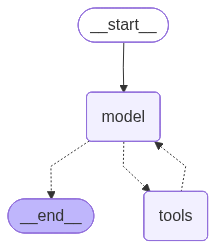

In [48]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

In [49]:
from langchain.messages import HumanMessage
import uuid
import sys

def _message_type(message) -> str:
    if isinstance(message, dict):
        return str(message.get("type", ""))
    return str(getattr(message, "type", ""))

def _message_content(message) -> str:
    if isinstance(message, dict):
        content = message.get("content", "")
    else:
        content = getattr(message, "content", "")

    if isinstance(content, list):
        return "\n".join(str(item) for item in content)
    return str(content) if content is not None else ""

def _read_user_input(prompt: str) -> tuple[str, bool]:
    """Read user input and detect Escape key presses when stdin supports raw mode."""
    if not sys.stdin or not sys.stdin.isatty():
        return input(prompt), False

    import termios
    import tty

    fd = sys.stdin.fileno()
    old_settings = termios.tcgetattr(fd)
    print(prompt, end="", flush=True)
    chars = []

    try:
        tty.setraw(fd)
        while True:
            ch = sys.stdin.read(1)
            if ch in {"\r", "\n"}:
                print()
                return "".join(chars), False
            if ch == "\x1b":
                print("\nChat ended.")
                return "", True
            if ch in {"\x7f", "\b"}:
                if chars:
                    chars.pop()
                    print("\b \b", end="", flush=True)
                continue
            if ch == "\x03":
                raise KeyboardInterrupt
            chars.append(ch)
            print(ch, end="", flush=True)
    finally:
        termios.tcsetattr(fd, termios.TCSADRAIN, old_settings)

def start_agent_session() -> dict:
    """Create a notebook-friendly chat session state."""
    return {
        "thread_id": str(uuid.uuid4()),
        "current_step": "receptionist",
        "terminal_steps": {"content_editor", "betting_editor"},
    }

def agent_chat_turn(session: dict, user_text: str) -> dict:
    """Run one chat turn without blocking input loops (recommended in notebooks)."""
    text = (user_text or "").strip()
    if not text:
        return {"status": "empty", "message": "Please enter a message."}

    chat_config = {"configurable": {"thread_id": session["thread_id"]}}
    payload = {"messages": [HumanMessage(text)]}

    # Terminal delivery steps should not persist to the next user turn.
    if session.get("current_step") in session.get("terminal_steps", set()):
        payload["current_step"] = "receptionist"

    result = agent.invoke(payload, chat_config)

    session["current_step"] = result.get("current_step", "receptionist")
    request_type = result.get("request_type", "not set")

    messages = result.get("messages", [])
    tool_messages = [_message_content(m) for m in messages if _message_type(m) == "tool"]

    latest_ai = ""
    for message in messages[::-1]:
        if _message_type(message) == "ai":
            latest_ai = _message_content(message)
            if latest_ai:
                break

    return {
        "status": "ok",
        "step": session["current_step"],
        "request_type": request_type,
        "tool_messages": tool_messages,
        "assistant": latest_ai if latest_ai else "(No assistant message returned)",
    }

def interactive_agent_chat():
    """Optional CLI-style loop. In notebooks, prefer start_agent_session + agent_chat_turn."""
    session = start_agent_session()
    quit_commands = {"exit", "quit", "q", "stop", "escape"}

    print("Interactive agent chat started")
    print("Type your message, or type: exit / quit / stop / escape")
    print("Press Escape to stop immediately (terminal stdin), or Ctrl+C anytime.")
    print("-" * 70)

    while True:
        try:
            user_text, escape_pressed = _read_user_input("You: ")
            if escape_pressed:
                break
            user_text = user_text.strip()
        except (EOFError, KeyboardInterrupt):
            print("\nChat ended.")
            break

        if user_text.lower() in quit_commands:
            print("Chat ended.")
            break
        if not user_text:
            continue

        try:
            out = agent_chat_turn(session, user_text)
        except KeyboardInterrupt:
            print("\nInterrupted by user. Chat ended.")
            break
        except Exception as error:
            print(f"\nAgent invocation failed: {error}")
            print("Resetting to receptionist step and continuing.")
            session["current_step"] = "receptionist"
            print("-" * 70)
            continue

        if out.get("tool_messages"):
            print("\nTool transitions:")
            for content in out["tool_messages"]:
                print(f"- {content}")

        print(f"\nStep: {out['step']}")
        print(f"Request type: {out['request_type']}")
        print("Assistant:")
        print(out["assistant"])
        print("-" * 70)

# print("Notebook tip: use single-turn calls to avoid stuck input loops.")
# print("session = start_agent_session()")
# print("agent_chat_turn(session, \"show me today's NBA games\")")
# print("agent_chat_turn(session, \"now show me expert picks for NBA\")")

# Run manually only if you want a blocking input loop:
interactive_agent_chat()

Interactive agent chat started
Type your message, or type: exit / quit / stop / escape
Press Escape to stop immediately (terminal stdin), or Ctrl+C anytime.
----------------------------------------------------------------------

Tool transitions:
- {
  "input": "next 10 days",
  "start_date": "20260309",
  "end_date": "20260319",
  "today": "20260309",
  "interpreted_as": "next_10_days",
  "note": "Use start_date/end_date with capture_user_request for games flow."
}
- Captured request_type=both, league=NBA, start_date=20260309, end_date=20260319, picks_status=UPCOMING.
- {"league": "NBA", "start_date": "20260309", "end_date": "20260319", "games_found": 86, "next_step": "betting_editor"}
- {
  "league": "NBA",
  "status": "UPCOMING",
  "total_picks": 8,
  "returned_edges": 8,
  "picks": [
    {
      "expert_name": "Matt Severance",
      "away_team": "New York",
      "home_team": "L.A. Clippers",
      "writeup": "Third road game in four nights and second of a back-to-back for the Kni